# Import Required Libraries
Import pandas, numpy, matplotlib, seaborn, and any other libraries needed for data loading and exploration.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load CSV Data
Use pandas.read_csv() to load housing.csv into a DataFrame, with file path handling and optional encoding settings.

In [4]:
import os

if os.path.exists("housing.csv"):
    df = pd.read_csv("housing.csv")
else:
    print(
        "housing.csv not found. Please download the California Housing Prices dataset from Kaggle: https://www.kaggle.com/datasets/camnugent/california-housing-prices"
    )
    print("Place the housing.csv file in the current directory.")
    df = None

# Inspect Dataset
Display DataFrame.head(), tail(), shape, dtypes, and DataFrame.info() to understand the data structure.

In [12]:
if df is not None:
    print("First 5 rows:")
    print(df[["median_house_value", "total_rooms", "total_bedrooms"]].head())
    print("\nLast 5 rows:")
    print(df.tail())
    print(f"\nShape: {df.shape}")
    print(f"\nData types:\n{df.dtypes}")
    print("\nInfo:")
    df.info()
else:
    print("Data not loaded.")

First 5 rows:
   median_house_value  total_rooms  total_bedrooms
0            452600.0        880.0           129.0
1            358500.0       7099.0          1106.0
2            352100.0       1467.0           190.0
3            341300.0       1274.0           235.0
4            342200.0       1627.0           280.0

Last 5 rows:
       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
20635    -121.09     39.48                25.0       1665.0           374.0   
20636    -121.21     39.49                18.0        697.0           150.0   
20637    -121.22     39.43                17.0       2254.0           485.0   
20638    -121.32     39.43                18.0       1860.0           409.0   
20639    -121.24     39.37                16.0       2785.0           616.0   

       population  households  median_income  median_house_value  \
20635       845.0       330.0         1.5603             78100.0   
20636       356.0       114.0         2.5568           

# Check Missing Values
Check for NaN/null value counts per column and decide on a strategy (dropna, fillna) for missing data.

In [10]:
if df is not None:
    print("Missing values per column:")
    print(df.isnull().sum())
    # Decide on strategy: e.g., df.dropna() or df.fillna(df.mean())
    df.dropna(inplace=True)
else:
    print("Data not loaded.")

Missing values per column:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


# Compute Summary Statistics
Use DataFrame.describe() and value_counts() for categorical features to summarize numeric and non-numeric columns.

In [11]:
if df is not None:
    print("Summary statistics for numeric columns:")
    print(df.describe())
    # For categorical features
    categorical_cols = df.select_dtypes(include=["object", "category"]).columns
    for col in categorical_cols:
        print(f"\nValue counts for {col}:")
        print(df[col].value_counts())
else:
    print("Data not loaded.")

Summary statistics for numeric columns:
          longitude      latitude  housing_median_age   total_rooms  \
count  20433.000000  20433.000000        20433.000000  20433.000000   
mean    -119.570689     35.633221           28.633094   2636.504233   
std        2.003578      2.136348           12.591805   2185.269567   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.800000     33.930000           18.000000   1450.000000   
50%     -118.490000     34.260000           29.000000   2127.000000   
75%     -118.010000     37.720000           37.000000   3143.000000   
max     -114.310000     41.950000           52.000000  39320.000000   

       total_bedrooms    population    households  median_income  \
count    20433.000000  20433.000000  20433.000000   20433.000000   
mean       537.870553   1424.946949    499.433465       3.871162   
std        421.385070   1133.208490    382.299226       1.899291   
min          1.000000      3.000000      1.00000

C:\Users\nkmil\AppData\Local\Temp\ipykernel_8972\1923051005.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object", "category"]).columns


# Basic Visualizations
Plot distributions, pairwise relations, and correlation heatmap to get initial insights into the housing data.

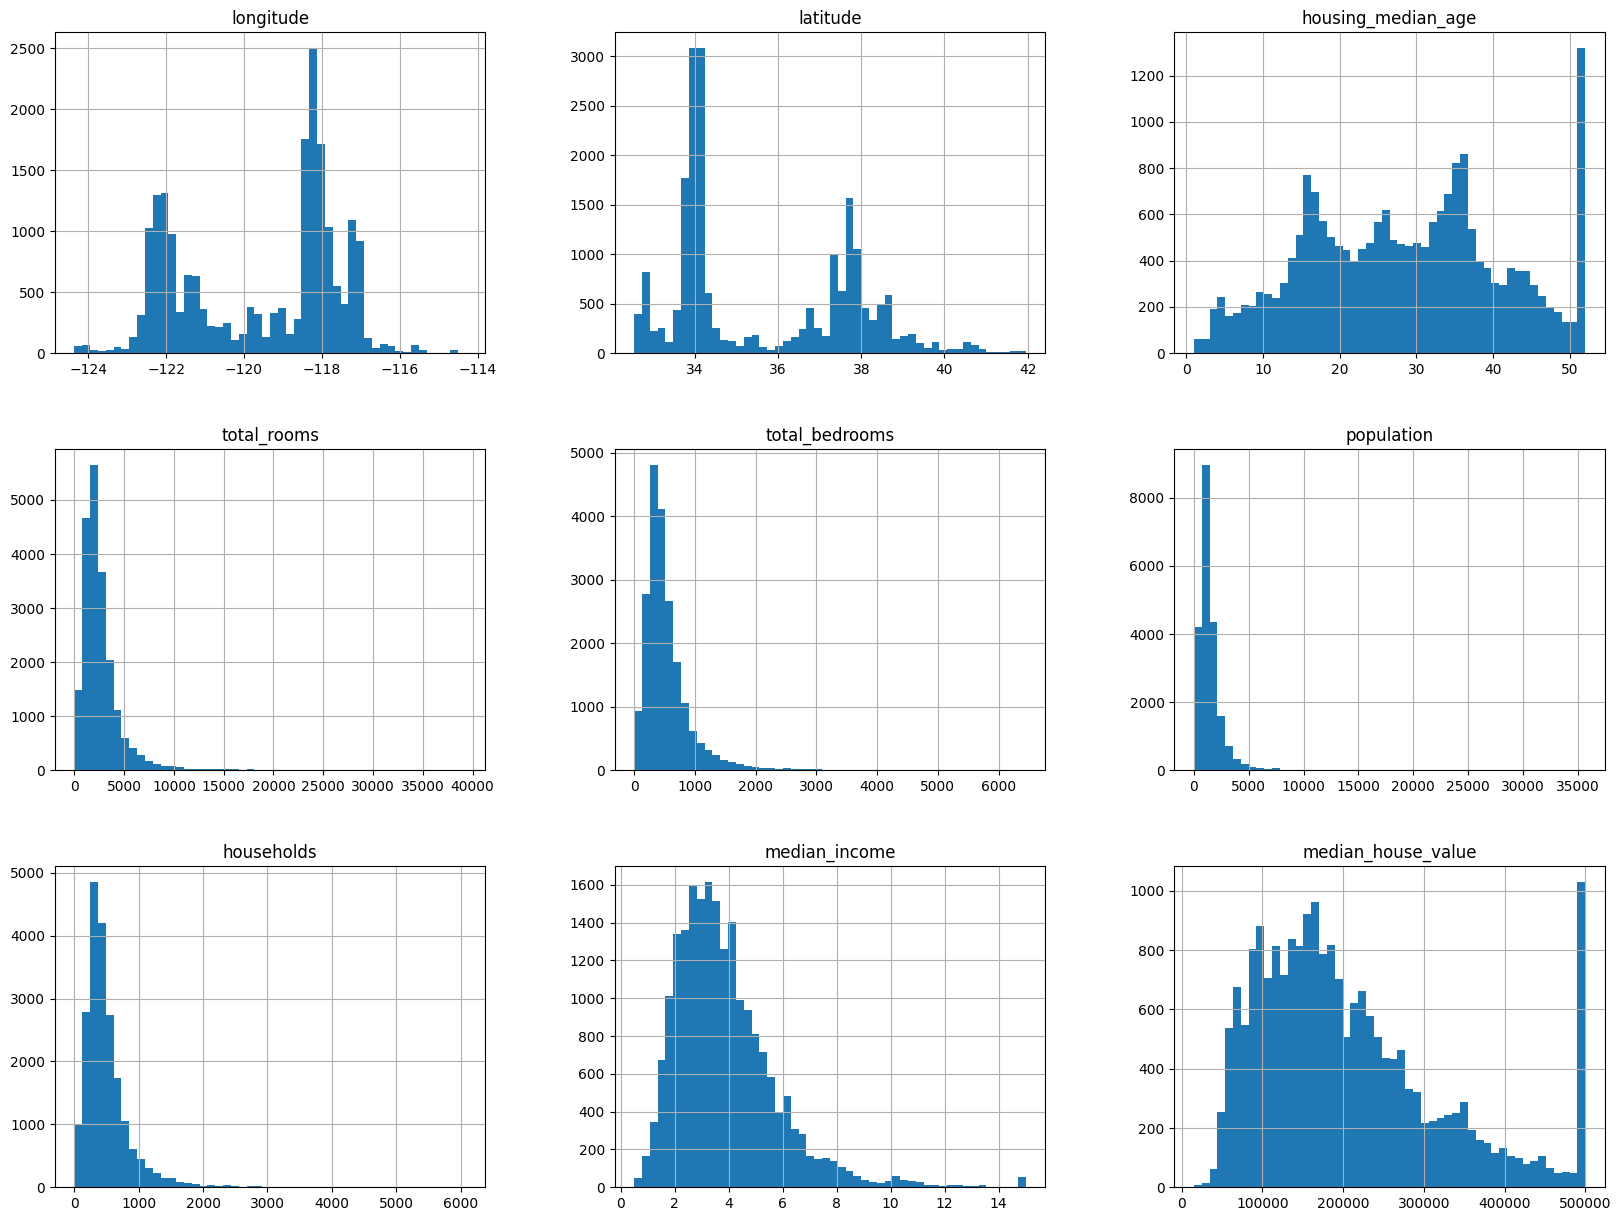

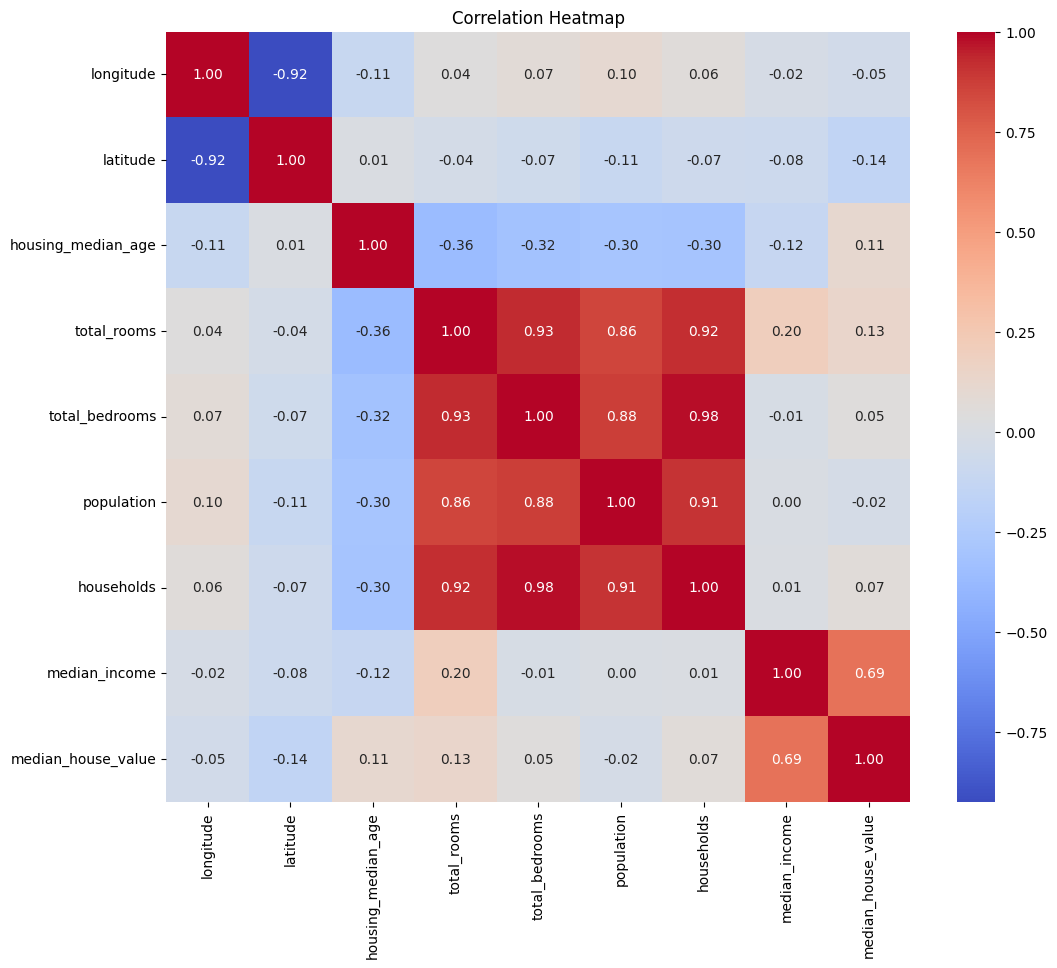

For pairwise relations, consider using sns.pairplot(df.sample(1000)) on a sample of the data.


In [9]:
if df is not None:
    # Distributions
    df.hist(bins=50, figsize=(20, 15))
    plt.show()

    # Correlation heatmap
    plt.figure(figsize=(12, 10))
    numeric_df = df.select_dtypes(include=[np.number])
    sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
    plt.title("Correlation Heatmap")
    plt.show()

    # Pairwise relations - note: can be slow for large datasets
    print("For pairwise relations, consider using sns.pairplot(df.sample(1000)) on a sample of the data.")
else:
    print("Data not loaded.")

# Additional Analysis: Distribution and Relationship Highlights
Compute extra statistics and group-based analysis for immediate interpretation.

--- Missing value fraction by column ---
longitude             0.0
latitude              0.0
housing_median_age    0.0
total_rooms           0.0
total_bedrooms        0.0
population            0.0
households            0.0
median_income         0.0
median_house_value    0.0
ocean_proximity       0.0
dtype: float64

--- Median house value quartiles ---
0.00     14999.0
0.25    119500.0
0.50    179700.0
0.75    264700.0
1.00    500001.0
Name: median_house_value, dtype: float64

--- Households by ocean proximity ---
ocean_proximity
<1H OCEAN     9034
INLAND        6496
NEAR OCEAN    2628
NEAR BAY      2270
ISLAND           5
Name: count, dtype: int64
ocean_proximity
ISLAND        414700.0
NEAR BAY      233800.0
NEAR OCEAN    228750.0
<1H OCEAN     215000.0
INLAND        108700.0
Name: median_house_value, dtype: float64

--- Correlation to median_house_value ---
median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
house

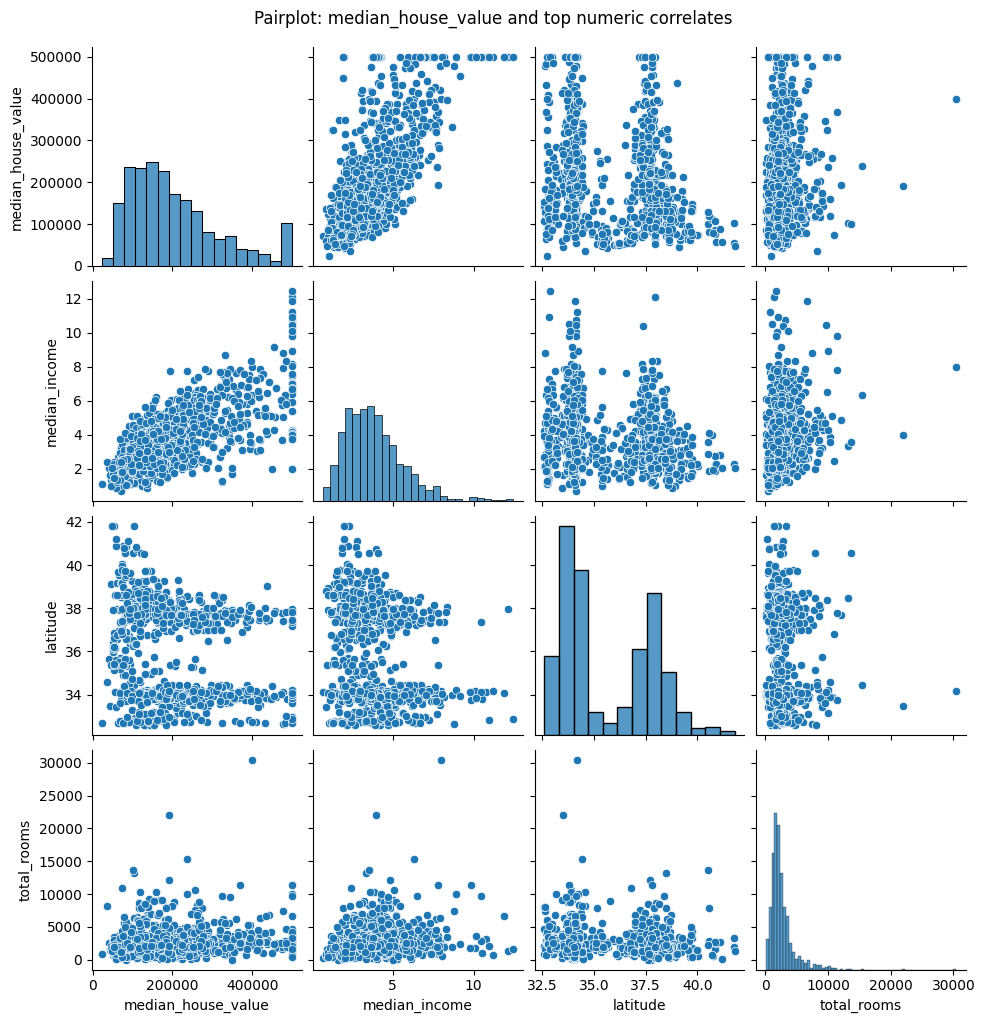

In [14]:
if df is not None:
    print("--- Missing value fraction by column ---")
    print((df.isna().mean() * 100).round(2))

    print("\n--- Median house value quartiles ---")
    print(df["median_house_value"].quantile([0.0, 0.25, 0.5, 0.75, 1.0]))

    print("\n--- Households by ocean proximity ---")
    if "ocean_proximity" in df.columns:
        print(df["ocean_proximity"].value_counts())
        print(df.groupby("ocean_proximity")["median_house_value"].median().sort_values(ascending=False))

    print("\n--- Correlation to median_house_value ---")
    corr_target = numeric_df.corr()["median_house_value"].sort_values(ascending=False)
    print(corr_target)

    # Scatter for top 3 positive correlations
    top3 = corr_target.drop("median_house_value").abs().sort_values(ascending=False).head(3).index
    print(f"\nTop 3 numeric correlations: {list(top3)}")
    sns.pairplot(df.sample(min(1000, len(df))), vars=["median_house_value"] + list(top3), height=2.5)
    plt.suptitle("Pairplot: median_house_value and top numeric correlates", y=1.02)
    plt.show()
else:
    print("Data not loaded; cannot analyze.")